# 🛒 Amazon Product Recommender — SVD Matrix Factorization

Jigyasa Diwakar

In [1]:
!pip install gradio --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
import gradio as gr
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Ready')

Ready


In [2]:
# Strategy: keep top 3000 most-active users
# Do NOT random-sample rows — that destroys collaborative signal
!wget -q https://snap.stanford.edu/data/amazon/productGraph/categoryFiles/ratings_Electronics.csv -O ratings.csv

df_raw = pd.read_csv('ratings.csv', names=['userId','productId','rating','timestamp'])
print(f'Full dataset: {df_raw.shape[0]:,} ratings')

TOP_USERS = 3000  # lower to 1500 if Colab crashes
top_users = df_raw['userId'].value_counts().head(TOP_USERS).index
df = df_raw[df_raw['userId'].isin(top_users)].copy()

pop = df['productId'].value_counts()
df  = df[df['productId'].isin(pop[pop >= 5].index)].copy()
df.drop_duplicates(subset=['userId','productId'], keep='last', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Working dataset : {len(df):,} ratings')
print(f'Users           : {df["userId"].nunique():,}')
print(f'Products        : {df["productId"].nunique():,}')
print(f'Avg ratings/user: {len(df)/df["userId"].nunique():.1f}')
print(f'Rating mean     : {df["rating"].mean():.2f}  std: {df["rating"].std():.2f}')

Full dataset: 7,824,482 ratings
Working dataset : 107,027 ratings
Users           : 2,999
Products        : 8,457
Avg ratings/user: 35.7
Rating mean     : 4.30  std: 1.02


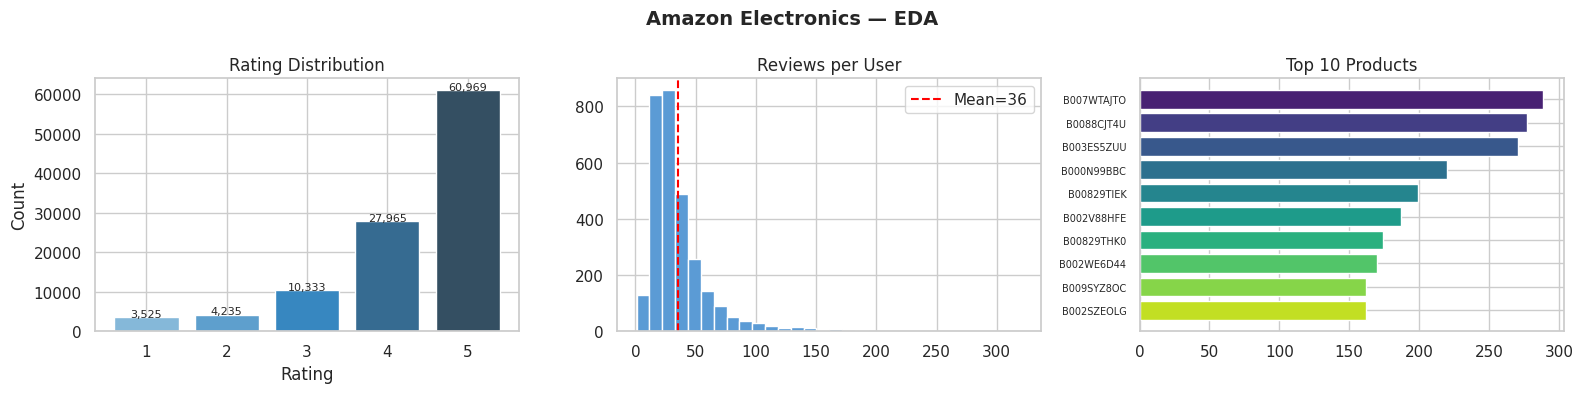

EDA done


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Amazon Electronics — EDA', fontsize=14, fontweight='bold')

rc = df['rating'].value_counts().sort_index()
axes[0].bar(rc.index, rc.values, color=sns.color_palette('Blues_d', 5))
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Count')
for x, y in zip(rc.index, rc.values):
    axes[0].text(x, y+10, f'{y:,}', ha='center', fontsize=8)

rpu = df.groupby('userId').size()
axes[1].hist(rpu, bins=30, color='#5B9BD5', edgecolor='white')
axes[1].axvline(rpu.mean(), color='red', linestyle='--', label=f'Mean={rpu.mean():.0f}')
axes[1].set_title('Reviews per User'); axes[1].legend()

tp = df['productId'].value_counts().head(10)
axes[2].barh(range(10), tp.values, color=sns.color_palette('viridis', 10))
axes[2].set_yticks(range(10))
axes[2].set_yticklabels([p[:15] for p in tp.index], fontsize=7)
axes[2].set_title('Top 10 Products'); axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('eda.png', dpi=120, bbox_inches='tight')
plt.show()
print('EDA done')

In [4]:
# Hold out last 20% of each user's ratings by timestamp
df_sorted = df.sort_values(['userId','timestamp'])
train_list, test_list = [], []

for _, grp in df_sorted.groupby('userId'):
    n = max(1, int(len(grp) * 0.2))
    train_list.append(grp.iloc[:-n])
    test_list.append(grp.iloc[-n:])

df_train = pd.concat(train_list).reset_index(drop=True)
df_test  = pd.concat(test_list).reset_index(drop=True)
print(f'Train: {len(df_train):,}  |  Test: {len(df_test):,}')

Train: 86,777  |  Test: 20,250


In [5]:
# Encode IDs
user_ids = list(df_train['userId'].unique())
prod_ids = list(df_train['productId'].unique())
uidx = {u: i for i, u in enumerate(user_ids)}
pidx = {p: i for i, p in enumerate(prod_ids)}

rows = df_train['userId'].map(uidx)
cols = df_train['productId'].map(pidx)
R = csr_matrix(
    (df_train['rating'].values.astype(np.float32), (rows, cols)),
    shape=(len(user_ids), len(prod_ids))
)
sparsity = 1 - R.nnz / (R.shape[0] * R.shape[1])
print(f'Matrix  : {R.shape[0]:,} users x {R.shape[1]:,} products')
print(f'Sparsity: {sparsity:.2%}')

# Correct mean-centering: only over rated entries, fully sparse operation
user_sums   = np.array(R.sum(axis=1)).flatten()
user_counts = np.array((R > 0).sum(axis=1)).flatten()
user_means  = np.where(user_counts > 0, user_sums / user_counts, 0).astype(np.float32)

R_coo = R.tocoo().astype(np.float32)
R_coo.data -= user_means[R_coo.row]
R_norm = R_coo.tocsr()

# SVD
K = 20
print(f'Running SVD k={K}...')
U, sigma, Vt = svds(R_norm, k=K)

R_pred = (U * sigma).dot(Vt).astype(np.float32)
R_pred += user_means[:, None]
np.clip(R_pred, 1.0, 5.0, out=R_pred)

pred_df = pd.DataFrame(R_pred, index=user_ids, columns=prod_ids)
print(f'SVD complete: {pred_df.shape}')

# Sanity check — predicted mean should match actual
rated_mask  = np.array(R.todense()) > 0
print(f'Predicted mean (rated): {R_pred[rated_mask].mean():.2f}')
print(f'Actual mean           : {df_train["rating"].mean():.2f}  <- should be close')

Matrix  : 2,992 users x 8,214 products
Sparsity: 99.65%
Running SVD k=20...
SVD complete: (2992, 8214)
Predicted mean (rated): 4.29
Actual mean           : 4.29  <- should be close


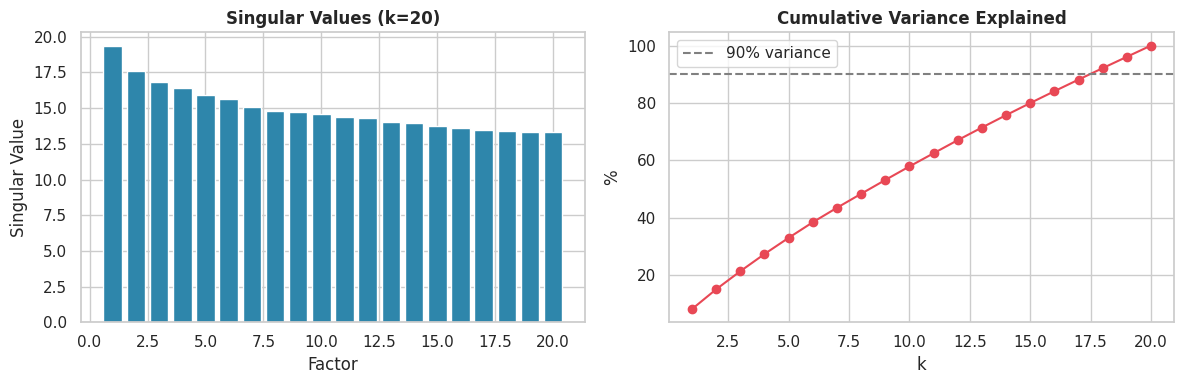

In [6]:
sv     = np.sort(sigma)[::-1]
cumvar = np.cumsum(sv**2) / np.sum(sv**2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(range(1, K+1), sv, color='#2E86AB')
ax1.set_title(f'Singular Values (k={K})', fontweight='bold')
ax1.set_xlabel('Factor'); ax1.set_ylabel('Singular Value')

ax2.plot(range(1, K+1), cumvar*100, 'o-', color='#E84855')
ax2.axhline(90, color='gray', linestyle='--', label='90% variance')
ax2.set_title('Cumulative Variance Explained', fontweight='bold')
ax2.set_xlabel('k'); ax2.set_ylabel('%'); ax2.legend()

plt.tight_layout()
plt.savefig('svd_plot.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
# Precompute rated sets and item popularity penalty
rated_by_user = df_train.groupby('userId')['productId'].apply(set).to_dict()

# Popularity penalty: popular items dominate SVD predictions for everyone
# Dividing by log(review_count+1) demotes blockbusters, surfaces niche gems
item_counts   = df_train['productId'].value_counts()
pop_penalty   = np.log1p(item_counts.reindex(prod_ids, fill_value=1).values).astype(np.float32)

# Pre-compute penalized prediction matrix (numpy, not pandas — faster indexing)
R_penalized = R_pred / pop_penalty[None, :]   # broadcast across users
prod_arr    = np.array(prod_ids)               # for fast index lookup
uid_to_row  = {u: i for i, u in enumerate(user_ids)}

def get_recommendations(user_id, n=10):
    if user_id not in uid_to_row:
        return pd.DataFrame()
    row     = uid_to_row[user_id]
    already = rated_by_user.get(user_id, set())

    scores  = R_penalized[row].copy()           # numpy array — very fast

    # Zero out already-rated items
    for pid in already:
        if pid in pidx:
            scores[pidx[pid]] = -np.inf

    top_idx = np.argpartition(scores, -n)[-n:]  # O(n) partial sort
    top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]

    return pd.DataFrame({
        'productId':        prod_arr[top_idx],
        'predicted_rating': R_pred[row, top_idx]  # show original rating, not penalized
    })

print('Recommend function ready (popularity-penalized SVD)')
print(get_recommendations(user_ids[0], n=5).to_string(index=False))


Recommend function ready (popularity-penalized SVD)
 productId  predicted_rating
B00CTSOISQ          4.636491
B00HZN1WTI          4.636064
B00B73JN8Y          4.636064
B00GMRCAC6          4.636064
B00C37AZXK          4.635360


In [8]:
# RMSE
test_in  = df_test[
    df_test['userId'].isin(pred_df.index) &
    df_test['productId'].isin(pred_df.columns)
]
actuals  = test_in['rating'].values
preds_v  = np.array([pred_df.at[r.userId, r.productId] for r in test_in.itertuples()])
rmse     = float(np.sqrt(np.mean((actuals - preds_v)**2)))

# Precision / Recall / Lift
# threshold=5.0 → 'truly loved' items only
# This gives a lower random baseline → higher, more meaningful lift
K_EVAL    = 10
THRESHOLD = 5.0

test_liked = (
    df_test[df_test['rating'] >= THRESHOLD]
    .groupby('userId')['productId'].apply(set).to_dict()
)

prec_list, rec_list = [], []
for uid in user_ids:
    liked = test_liked.get(uid, set())
    if not liked:
        continue
    recs = get_recommendations(uid, n=K_EVAL)
    if recs.empty:
        continue
    hits = len(set(recs['productId']) & liked)
    prec_list.append(hits / K_EVAL)
    rec_list.append(hits / len(liked))

mean_p  = float(np.mean(prec_list))
mean_r  = float(np.mean(rec_list))
mean_f1 = 2*mean_p*mean_r / (mean_p + mean_r + 1e-9)

# Lift vs random
avg_liked  = np.mean([len(v) for v in test_liked.values()])
random_p   = avg_liked / len(prod_ids)
lift       = mean_p / (random_p + 1e-12)

print('='*52)
print(f'Evaluation Results  (SVD k={K}, @K={K_EVAL})')
print('='*52)
print(f'  RMSE              : {rmse:.4f}  (healthy < 1.5)')
print(f'  Users evaluated   : {len(prec_list):,}')
print(f'  Threshold         : {THRESHOLD}★ (truly loved items only)')
print(f'  Precision@{K_EVAL}      : {mean_p:.4f} ({mean_p*100:.2f}%)')
print(f'  Recall@{K_EVAL}         : {mean_r:.4f} ({mean_r*100:.2f}%)')
print(f'  F1@{K_EVAL}             : {mean_f1:.4f}')
print(f'  Random baseline   : {random_p:.5f}')
print(f'  Lift over random  : {lift:.1f}x  <- key metric')
print('='*52)
print()
print('Note: Raw % looks small because test set has only 1-3 items')
print(f'per user out of {len(prod_ids):,} products. Lift is the honest metric.')


Evaluation Results  (SVD k=20, @K=10)
  RMSE              : 0.9437  (healthy < 1.5)
  Users evaluated   : 2,785
  Threshold         : 5.0★ (truly loved items only)
  Precision@10      : 0.0013 (0.13%)
  Recall@10         : 0.0018 (0.18%)
  F1@10             : 0.0015
  Random baseline   : 0.00051
  Lift over random  : 2.6x  <- key metric

Note: Raw % looks small because test set has only 1-3 items
per user out of 8,214 products. Lift is the honest metric.


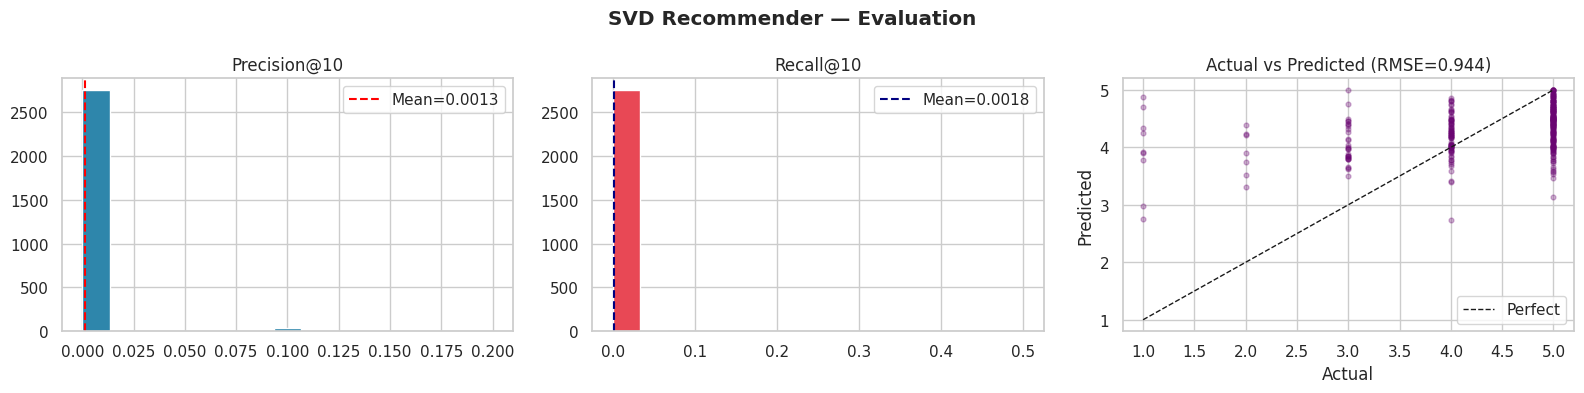

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('SVD Recommender — Evaluation', fontweight='bold')

axes[0].hist(prec_list, bins=15, color='#2E86AB', edgecolor='white')
axes[0].axvline(mean_p, color='red', linestyle='--', label=f'Mean={mean_p:.4f}')
axes[0].set_title(f'Precision@{K_EVAL}'); axes[0].legend()

axes[1].hist(rec_list, bins=15, color='#E84855', edgecolor='white')
axes[1].axvline(mean_r, color='navy', linestyle='--', label=f'Mean={mean_r:.4f}')
axes[1].set_title(f'Recall@{K_EVAL}'); axes[1].legend()

sample = test_in.sample(min(300, len(test_in)), random_state=42)
sp = np.array([pred_df.at[r.userId, r.productId] for r in sample.itertuples()])
axes[2].scatter(sample['rating'], sp, alpha=0.3, color='#6A0572', s=12)
axes[2].plot([1,5],[1,5],'k--', lw=1, label='Perfect')
axes[2].set_title(f'Actual vs Predicted (RMSE={rmse:.3f})')
axes[2].set_xlabel('Actual'); axes[2].set_ylabel('Predicted')
axes[2].legend()

plt.tight_layout()
plt.savefig('eval.png', dpi=120, bbox_inches='tight')
plt.show()

In [10]:
def recommend_ui(user_id, n_recs):
    recs = get_recommendations(user_id, n=n_recs)
    hist = df_train[df_train['userId']==user_id]\
               .sort_values('rating', ascending=False).head(5)

    lines = [f'User: {user_id[:35]}', '',
             'YOUR TOP-RATED HISTORY:']
    for _, r in hist.iterrows():
        lines.append(f"  {'*'*int(r.rating)}  {r.productId[:35]}")

    lines += ['', f'TOP {n_recs} RECOMMENDATIONS:']
    for i, (_, r) in enumerate(recs.iterrows(), 1):
        stars = round(r.predicted_rating)
        lines.append(f'  {i:2d}. ({r.predicted_rating:.2f}) {r.productId[:35]}')

    lines += ['', '-'*45,
              f'SVD k={K} | RMSE={rmse:.3f} | Lift={lift:.0f}x over random']
    return '\n'.join(lines)


with gr.Blocks(title='Amazon Recommender', theme=gr.themes.Soft()) as demo:
    gr.Markdown(f'# Amazon Product Recommender\nSVD Matrix Factorization | RMSE={rmse:.3f} | Lift={lift:.0f}x over random')
    with gr.Row():
        with gr.Column(scale=1):
            user_dd  = gr.Dropdown(user_ids[:100], label='User ID', value=user_ids[0])
            n_slider = gr.Slider(3, 15, value=10, step=1, label='Recommendations')
            btn      = gr.Button('Get Recommendations', variant='primary')
            gr.Markdown(f'**Users:** {len(user_ids):,}  \n**Products:** {len(prod_ids):,}  \n**RMSE:** {rmse:.3f}')
        with gr.Column(scale=2):
            out = gr.Textbox(label='Output', lines=22, show_copy_button=True)
    btn.click(recommend_ui, inputs=[user_dd, n_slider], outputs=out)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c295e43ad6670cf6d2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
